In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import cftime
import datetime
from datetime import date
from matplotlib import pyplot
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy
import pandas
import xarray as xr

In [2]:
# Ignore warnings
numpy.seterr(invalid="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [3]:
# Define directories
Diri = '../ExtraTrack_Data/Output_Files_V7/'
Output_Diri = '../RCP_Figs/Analysis_Figs_V7.4.1/'

In [4]:
# Open file
def Open_File(File):
    DF = pandas.read_csv(File)
    DF = DF.drop("Unnamed: 0", axis=1)
    return (DF)

In [5]:
# Open each file
def Files_Open(Scenario, Diri, Subset):
    Data_DF = Open_File(Diri+Scenario+'_Data_'+Subset+'_Output.csv')
    ET_DF = Open_File(Diri+Scenario+'_ET_'+Subset+'_Output.csv')
    Codes_DF = Open_File(Diri+Scenario+'_Codes_Output.csv')
# Edit time format
    Time_Cols = ["ET Begin Time", "ET Complete Time", "Trop Peak Time", "Peak Time", "Genesis Time", "Final Time"]
    for Col in Time_Cols:
        ET_DF[Col] = pandas.to_datetime(ET_DF[Col], errors="coerce")
    Data_DF["Time(Z)"] = pandas.to_datetime(Data_DF["Time(Z)"], errors="coerce")
    return (Data_DF, ET_DF, Codes_DF)

In [6]:
# Create bins
def Create_Bins(Min, Max, Bin_Width):
    Bins = numpy.arange(Min, Max+Bin_Width, Bin_Width)
    return (Bins)

In [7]:
# Number of years for each climate scenario
Num_Years = numpy.array([90,93,93])

In [8]:
# Open files
Control_Data, Control_ET, Control_Codes = Files_Open("Control", Diri, "SubsetB")
RCP45_Data, RCP45_ET, RCP45_Codes = Files_Open("RCP45", Diri, "SubsetB")
RCP85_Data, RCP85_ET, RCP85_Codes = Files_Open("RCP85", Diri, "SubsetB")

In [9]:
# Create function to plot tropical peak, ET initiation and completion locations
def Plot_ET_Locs(Fig, ET_DF, Scenario, i):
#
# Plot tropical peak locations
    Axis = Fig.add_subplot(3,3,3*i+1, projection=ccrs.PlateCarree())
    ET_DF_Trop_Peak = ET_DF[ET_DF["Trop Peak SLP"] <= 1000].reset_index(drop=True)
    Trop_Peak_Lats = numpy.array(ET_DF_Trop_Peak["Trop Peak Lat"])
    Trop_Peak_Lons = numpy.array(ET_DF_Trop_Peak["Trop Peak Lon"])
    Axis.scatter(Trop_Peak_Lons, Trop_Peak_Lats, marker='*', linewidths=1.8, \
    facecolors='none', edgecolors='black', s=28)
    Plot_Map_Formatting(Axis, 3*i, -100, 10, 0, 60)
    Title = Scenario + ": Trop Peak Locations"
    Axis.set_title(Title, fontsize=24)
#
# Plot ET begin locations
    Axis = Fig.add_subplot(3,3,3*i+2, projection=ccrs.PlateCarree())
    ET_DF_Begin = ET_DF[ET_DF["ET Begin SLP"] <= 1010].reset_index(drop=True)
    Begin_Lats = numpy.array(ET_DF_Begin["ET Begin Lat"])
    Begin_Lons = numpy.array(ET_DF_Begin["ET Begin Lon"])
    Axis.scatter(Begin_Lons, Begin_Lats, marker='s', linewidths=1.8, \
    facecolors='none', edgecolors='black', s=28)
    Plot_Map_Formatting(Axis, 3*i+1, -100, 10, 0, 60)
    Title = Scenario + ": ET Initiation Locations"
    Axis.set_title(Title, fontsize=24)
#
# Plot ET complete locations
    Axis = Fig.add_subplot(3,3,3*i+3, projection=ccrs.PlateCarree())
    ET_DF_Compl = ET_DF[ET_DF["ET Complete SLP"] <= 1010].reset_index(drop=True)
    Compl_Lats = numpy.array(ET_DF_Compl["ET Complete Lat"])
    Compl_Lons = numpy.array(ET_DF_Compl["ET Complete Lon"])
    Axis.scatter(Compl_Lons, Compl_Lats, marker='^', linewidths=1.8, \
    facecolors='none', edgecolors='black', s=28)
    Plot_Map_Formatting(Axis, 3*i+2, -100, 10, 0, 60)
    Title = Scenario + ": ET Completion Locations"
    Axis.set_title(Title, fontsize=24)

In [10]:
# Formatting
def Plot_Map_Formatting(Axis, Plot, x_Min, x_Max, y_Min, y_Max):
    Axis.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.5)
    Axis.add_feature(cfeature.BORDERS, linewidth=0.5)
    Axis.add_feature(cfeature.STATES, linewidth=0.3)
    x_Axis = Create_Bins(x_Min, x_Max, 10)
    y_Axis = Create_Bins(y_Min, y_Max, 10)
    Axis.set_xticks(x_Axis)
    Axis.set_yticks(y_Axis)
    Axis.set_xlim(x_Min,x_Max)
    Axis.set_ylim(y_Min,y_Max)
    Gridline = Axis.grid(linewidth=0.3, color='silver', linestyle='-')
    Letter_Label(Axis, Plot)

In [11]:
# Create subsets for each storm phase
def Phase_Subsets(Data):
    Subset_0 = Data[Data["SLP(hPa)"] <= 1010].reset_index()
    Subset_Trop = Subset_0[Subset_0["Storm Phase"] == "Tropical"]
    Subset_Trans = Subset_0[Subset_0["Storm Phase"] == "Transition"]
    Subset_Extra = Subset_0[Subset_0["Storm Phase"] == "Extratropical"]
    return (Subset_0, Subset_Trop, Subset_Trans, Subset_Extra)

In [12]:
# Build track density
def Build_Track_Density(Lons, Lats, Lon_Bins, Lat_Bins):
    Lons = numpy.array(Lons)
    Lats = numpy.array(Lats)
    Histo, Lon_Edges, Lat_Edges = numpy.histogram2d(Lons, Lats, bins=[Lon_Bins, Lat_Bins])
    Density = Histo.T
    Lon_Centers = 0.5 * (Lon_Edges[:-1] + Lon_Edges[1:])
    Lat_Centers = 0.5 * (Lat_Edges[:-1] + Lat_Edges[1:])
    return (Density, Lon_Centers, Lat_Centers)

In [13]:
# Box filter smoothing
def Smooth_2D(Box, k):
    if k <= 1:
        return (Box)
    elif k % 2 == 0:
        raise ValueError("k must be odd")
    Pad = k // 2
    x = numpy.pad(Box, ((Pad, Pad), (Pad, Pad)), mode="edge")
    Output = numpy.empty_like(Box, dtype=float)
    for i in range(Output.shape[0]):
        for j in range(Output.shape[1]):
            Output[i, j] = x[i:i+k, j:j+k].mean()
    return (Output)

In [14]:
# Create function to calculate track density by phase
def Phase_Locs_Distr(Data_DF, Lon_Bins, Lat_Bins):
# Create subsets based on phase
    Subset_0, Subset_Trop, Subset_Trans, Subset_Extra = Phase_Subsets(Data_DF)
#
# Count distribution of datapoints by phase
    Trop_Count, Lon_Centers, Lat_Centers = Build_Track_Density(Subset_Trop["Lon"], Subset_Trop["Lat"], Lon_Bins, Lat_Bins)
    Trans_Count, Lon_Centers, Lat_Centers = Build_Track_Density(Subset_Trans["Lon"], Subset_Trans["Lat"], Lon_Bins, Lat_Bins)
    Extra_Count, Lon_Centers, Lat_Centers = Build_Track_Density(Subset_Extra["Lon"], Subset_Extra["Lat"], Lon_Bins, Lat_Bins)
#
# Apply smoothing
    Trop_Count_Smooth = Smooth_2D(Trop_Count, 7)
    Trans_Count_Smooth = Smooth_2D(Trans_Count, 7)
    Extra_Count_Smooth = Smooth_2D(Extra_Count, 7)
#
# Calculate density
    Trop_Density = Trop_Count_Smooth / len(Subset_Trop) * 10000
    Trans_Density = Trans_Count_Smooth / len(Subset_Trans) * 10000
    Extra_Density = Extra_Count_Smooth / len(Subset_Extra) * 10000
    return (Trop_Density, Trans_Density, Extra_Density, Lon_Centers, Lat_Centers)

In [15]:
# Create function to plot track density based on phase
def Phase_Distr_Plot(Data_DF, Scenario, i, Bounds, Colours, Lon_Bins, Lat_Bins, Colourbar):
# Use function to calculate distributions
    Trop_Density, Trans_Density, Extra_Density, Lon_Centers, Lat_Centers = Phase_Locs_Distr(Data_DF, Lon_Bins, Lat_Bins)
#
# Build colour map
    C_Map = mcolors.ListedColormap(Colours)
    Norm = mcolors.BoundaryNorm(Bounds, C_Map.N, extend='max')
#
# Plot tropical track density
    Axis = Fig.add_subplot(3,3,i*3+1, projection=ccrs.PlateCarree())
    Image = Axis.pcolormesh(Lon_Centers, Lat_Centers, Trop_Density, shading="auto", cmap=C_Map, norm=Norm)
    Plot_Map_Formatting(Axis, i*3, -100, 10, 0, 60)
    Title = Scenario + ": Tropical Track Density"
    Axis.set_title(Title, fontsize=20)
#
# Plot transitioning track density
    Axis = Fig.add_subplot(3,3,i*3+2, projection=ccrs.PlateCarree())
    Image = Axis.pcolormesh(Lon_Centers, Lat_Centers, Trans_Density, shading="auto", cmap=C_Map, norm=Norm)
    Plot_Map_Formatting(Axis, i*3+1, -100, 10, 0, 60)
    Title = Scenario + ": Transitioning Track Density"
    Axis.set_title(Title, fontsize=20)
#
# Colour bar
    if Colourbar == True:
        Cbar_Label = 'Frequency (Per 10000 Data Points)'
        Cax = Axis.inset_axes([0.05, -0.14, 0.9, 0.05], transform=Axis.transAxes)
        Fig.colorbar(ScalarMappable(cmap=C_Map, norm=Norm), orientation='horizontal', cax=Cax, ticks=Bounds, \
        label=Cbar_Label)
#
# Plot extratropical track density
    Axis = Fig.add_subplot(3,3,i*3+3, projection=ccrs.PlateCarree())
    Image = Axis.pcolormesh(Lon_Centers, Lat_Centers, Extra_Density, shading="auto", cmap=C_Map, norm=Norm)
    Plot_Map_Formatting(Axis, i*3+2, -100, 10, 0, 60)
    Title = Scenario + ": Extratropical Track Density"
    Axis.set_title(Title, fontsize=20)

In [16]:
# Calculate difference between scenarios
def Phase_Locs_Diff(Density_1, Density_2):
    Diff = Density_1 - Density_2
# Mask cells where both scenarios have zero density
    No_Data = (Density_1 == 0) & (Density_2 == 0)
    Diff_Masked = numpy.ma.masked_where(No_Data, Diff)
    return (Diff_Masked)

In [17]:
# Create function to plot track density differences by phase
def Phase_Diff_Plot(Data_DF_1, Data_DF_2, Scenario_1, Scenario_2, i, Bounds, Colours, Lon_Bins, Lat_Bins, Colourbar):
    Trop_1, Trans_1, Extra_1, Lon_Centers, Lat_Centers = Phase_Locs_Distr(Data_DF_1, Lon_Bins, Lat_Bins)
    Trop_2, Trans_2, Extra_2, Lon_Centers, Lat_Centers = Phase_Locs_Distr(Data_DF_2, Lon_Bins, Lat_Bins)
    Trop_Diff = Phase_Locs_Diff(Trop_1, Trop_2)
    Trans_Diff = Phase_Locs_Diff(Trans_1, Trans_2)
    Extra_Diff = Phase_Locs_Diff(Extra_1, Extra_2)
#
# Build colour map
    C_Map = mcolors.ListedColormap(Colours)
    Norm = mcolors.BoundaryNorm(Bounds, C_Map.N, extend='both')
#
# Plot tropical track density difference
    Axis = Fig.add_subplot(3,3,i*3+1, projection=ccrs.PlateCarree())
    Image = Axis.pcolormesh(Lon_Centers, Lat_Centers, Trop_Diff, shading="auto", cmap=C_Map, norm=Norm)
    Plot_Map_Formatting(Axis, i*3, -100, 10, 0, 60)
    Title = Scenario_1 + " - " + Scenario_2 + ": Diff in Tropical Track Density"
    Axis.set_title(Title, fontsize=20)
#
# Plot transitioning track density difference
    Axis = Fig.add_subplot(3,3,i*3+2, projection=ccrs.PlateCarree())
    Image = Axis.pcolormesh(Lon_Centers, Lat_Centers, Trans_Diff, shading="auto", cmap=C_Map, norm=Norm)
    Plot_Map_Formatting(Axis, i*3+1, -100, 10, 0, 60)
    Title = Scenario_1 + " - " + Scenario_2 + ": Diff in Transitioning Track Density"
    Axis.set_title(Title, fontsize=20)
#
# Colour bar
    if Colourbar == True:
        Cbar_Label = 'Frequency Diff (Per 10000 Data Points)'
        Cax = Axis.inset_axes([0.05, -0.14, 0.9, 0.05], transform=Axis.transAxes)
        Fig.colorbar(ScalarMappable(cmap=C_Map, norm=Norm), orientation='horizontal', cax=Cax, ticks=Bounds, \
        label=Cbar_Label)
#
# Plot extratropical track density difference
    Axis = Fig.add_subplot(3,3,i*3+3, projection=ccrs.PlateCarree())
    Image = Axis.pcolormesh(Lon_Centers, Lat_Centers, Extra_Diff, shading="auto", cmap=C_Map, norm=Norm)
    Plot_Map_Formatting(Axis, i*3+2, -100, 10, 0, 60)
    Title = Scenario_1 + " - " + Scenario_2 + ": Diff in Extratropical Track Density"
    Axis.set_title(Title, fontsize=20)

In [18]:
# Letter labels
def Letter_Label(Axis, Plot):
    Fig_Labels = ['(a)','(b)','(c)','(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)']
    Axis.text(0.03, 0.92, str(Fig_Labels[int(Plot)]), ha='center', va='center', \
    transform=Axis.transAxes, fontdict={'size':24},color='black')

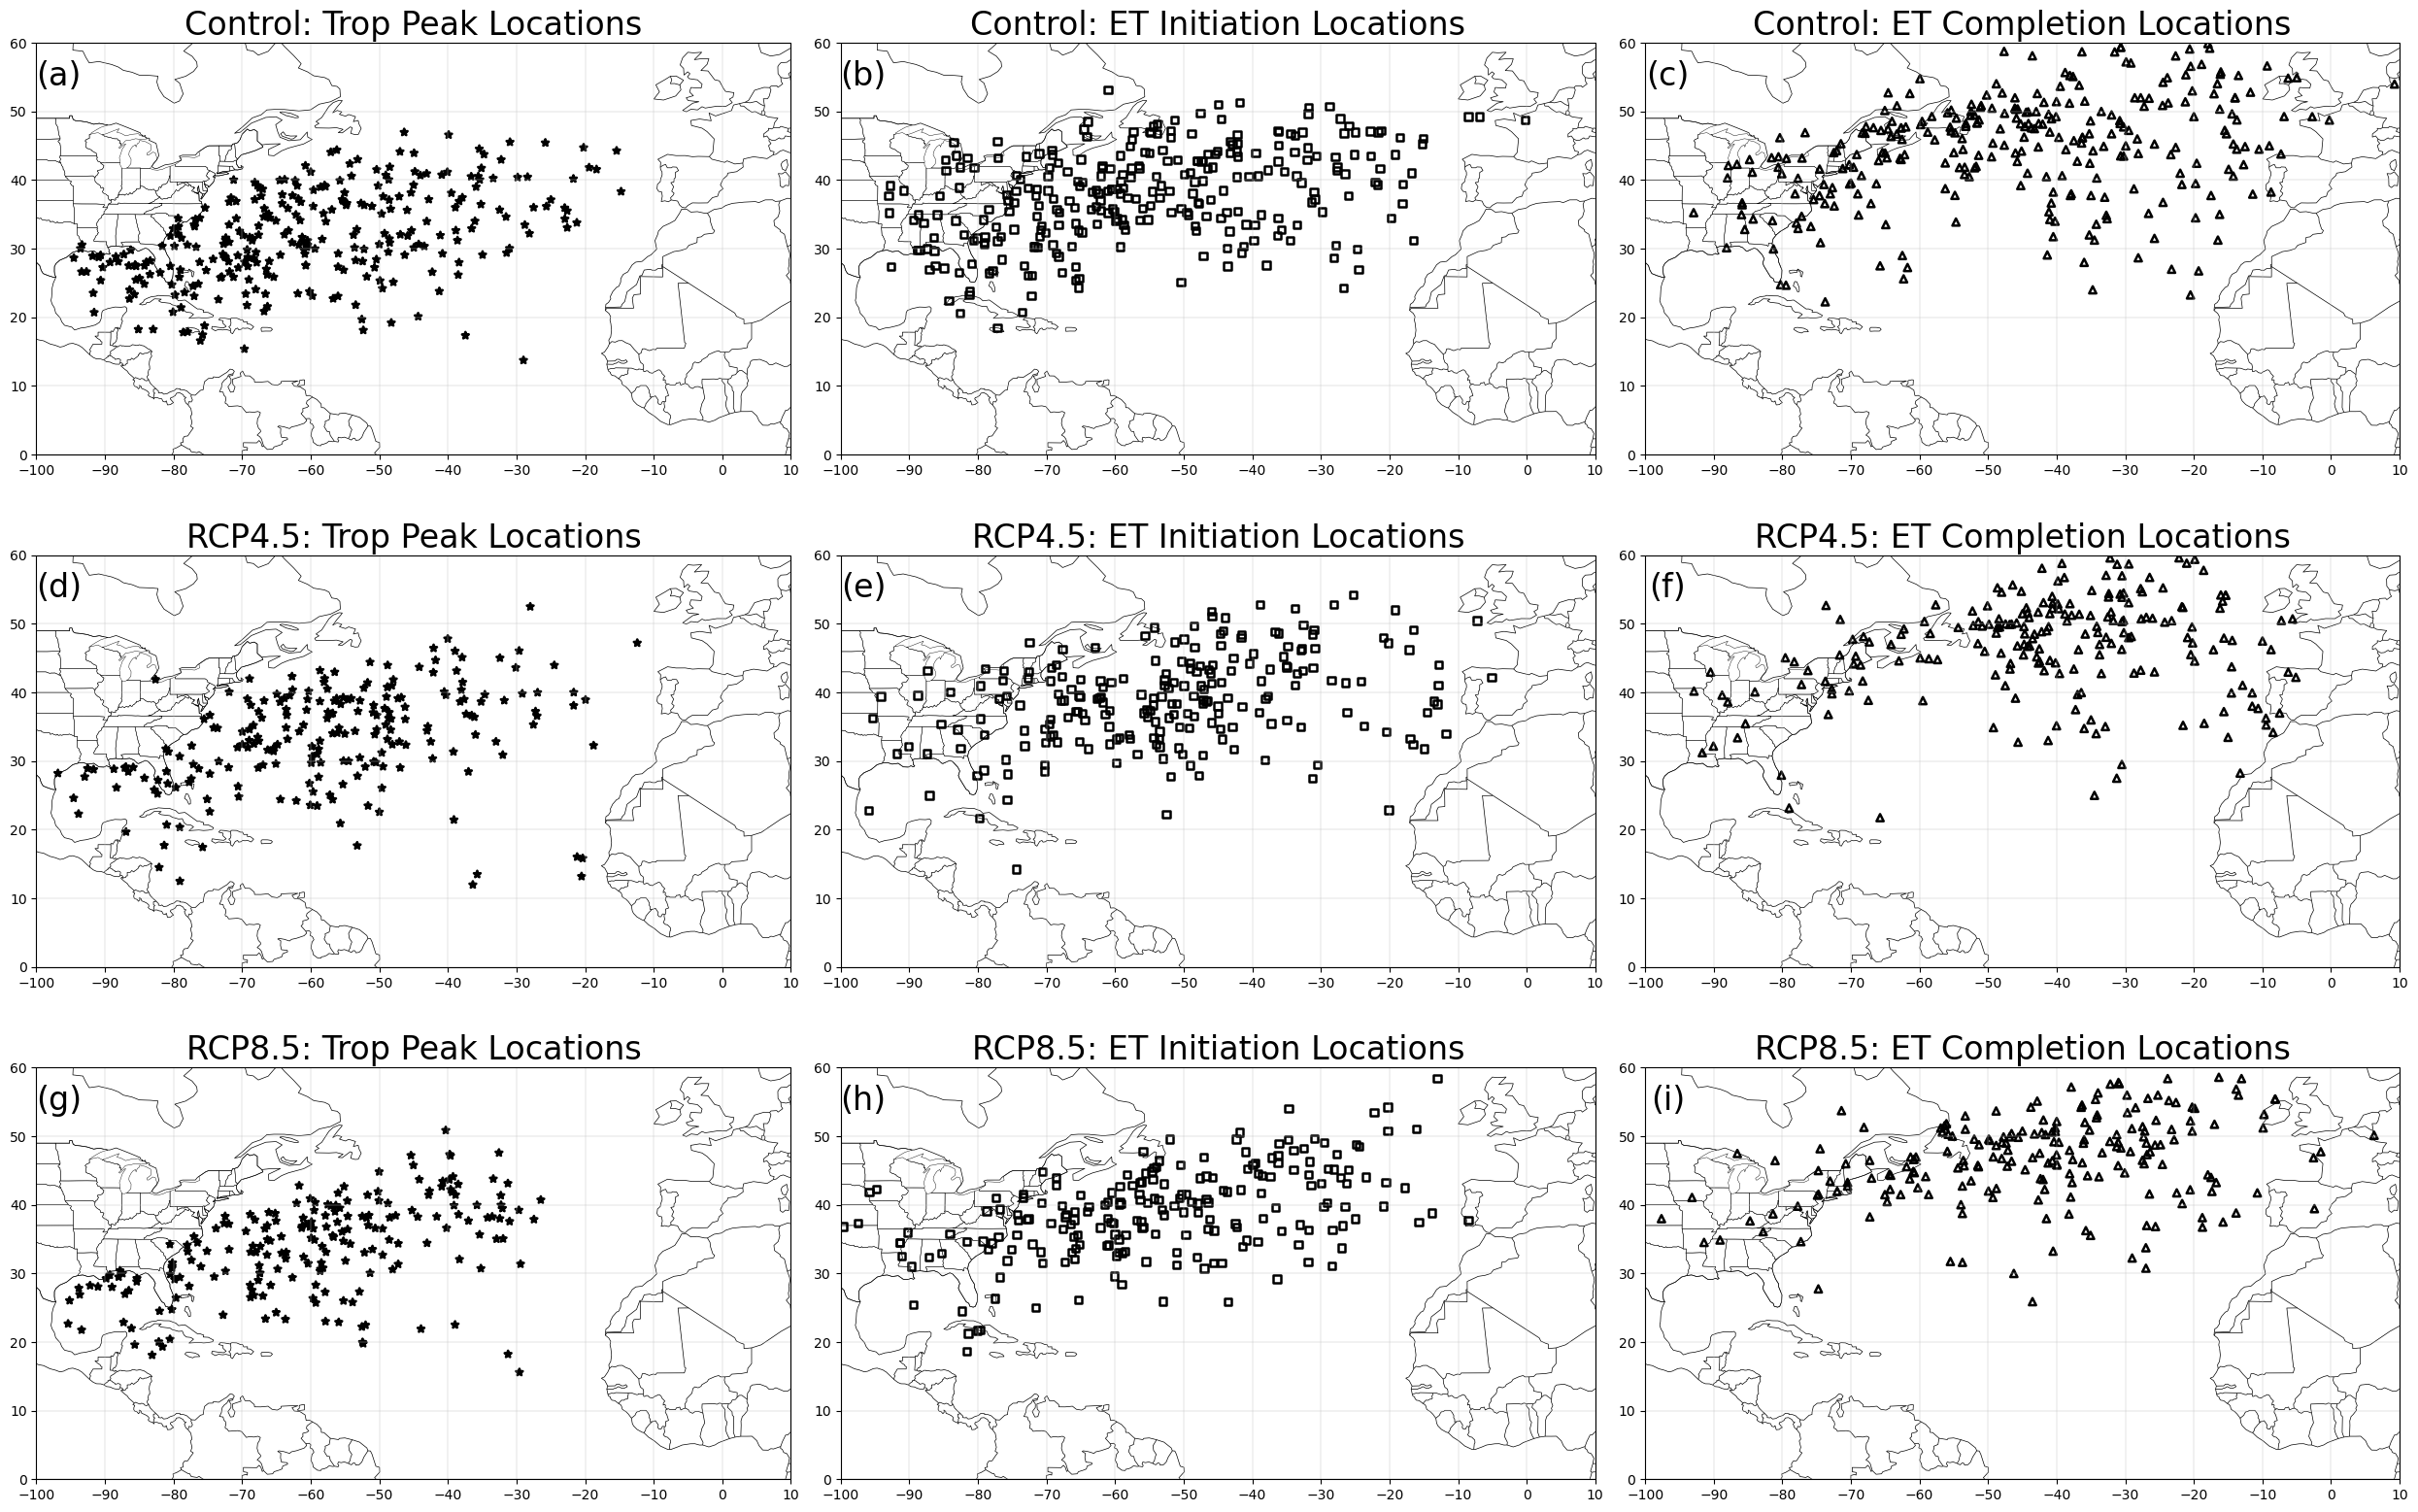

In [19]:
# Plot tropical peak, ET initiation and ET completion locations
Fig = pyplot.figure(figsize=(25,16))
Plot_ET_Locs(Fig, Control_ET, "Control", 0)
Plot_ET_Locs(Fig, RCP45_ET, "RCP4.5", 1)
Plot_ET_Locs(Fig, RCP85_ET, "RCP8.5", 2)
Fig.tight_layout()
Fig.savefig(Output_Diri+'ET_Locs.png', bbox_inches='tight')

In [20]:
# Define bins
Lat_Bins = Create_Bins(0,60,2)
Lon_Bins = Create_Bins(-100,10,2)

In [21]:
# Define track density colours
Phase_Colours = ['white', 'lightskyblue', 'deepskyblue', 'lightseagreen', 'limegreen', 'greenyellow', 'yellow', 'orange', 'red']
Phase_Bounds = numpy.array([0,1e-8,5,10,15,20,25,30,45])
#
# Define track density difference colours
Phase_Diff_Colours = ['mediumblue', 'dodgerblue', 'deepskyblue', 'cyan', 'lawngreen', \
'gold', 'orange', 'darkorange', 'red']
Phase_Diff_Bounds = numpy.array([-15,-10,-6,-3,3,6,10,15])

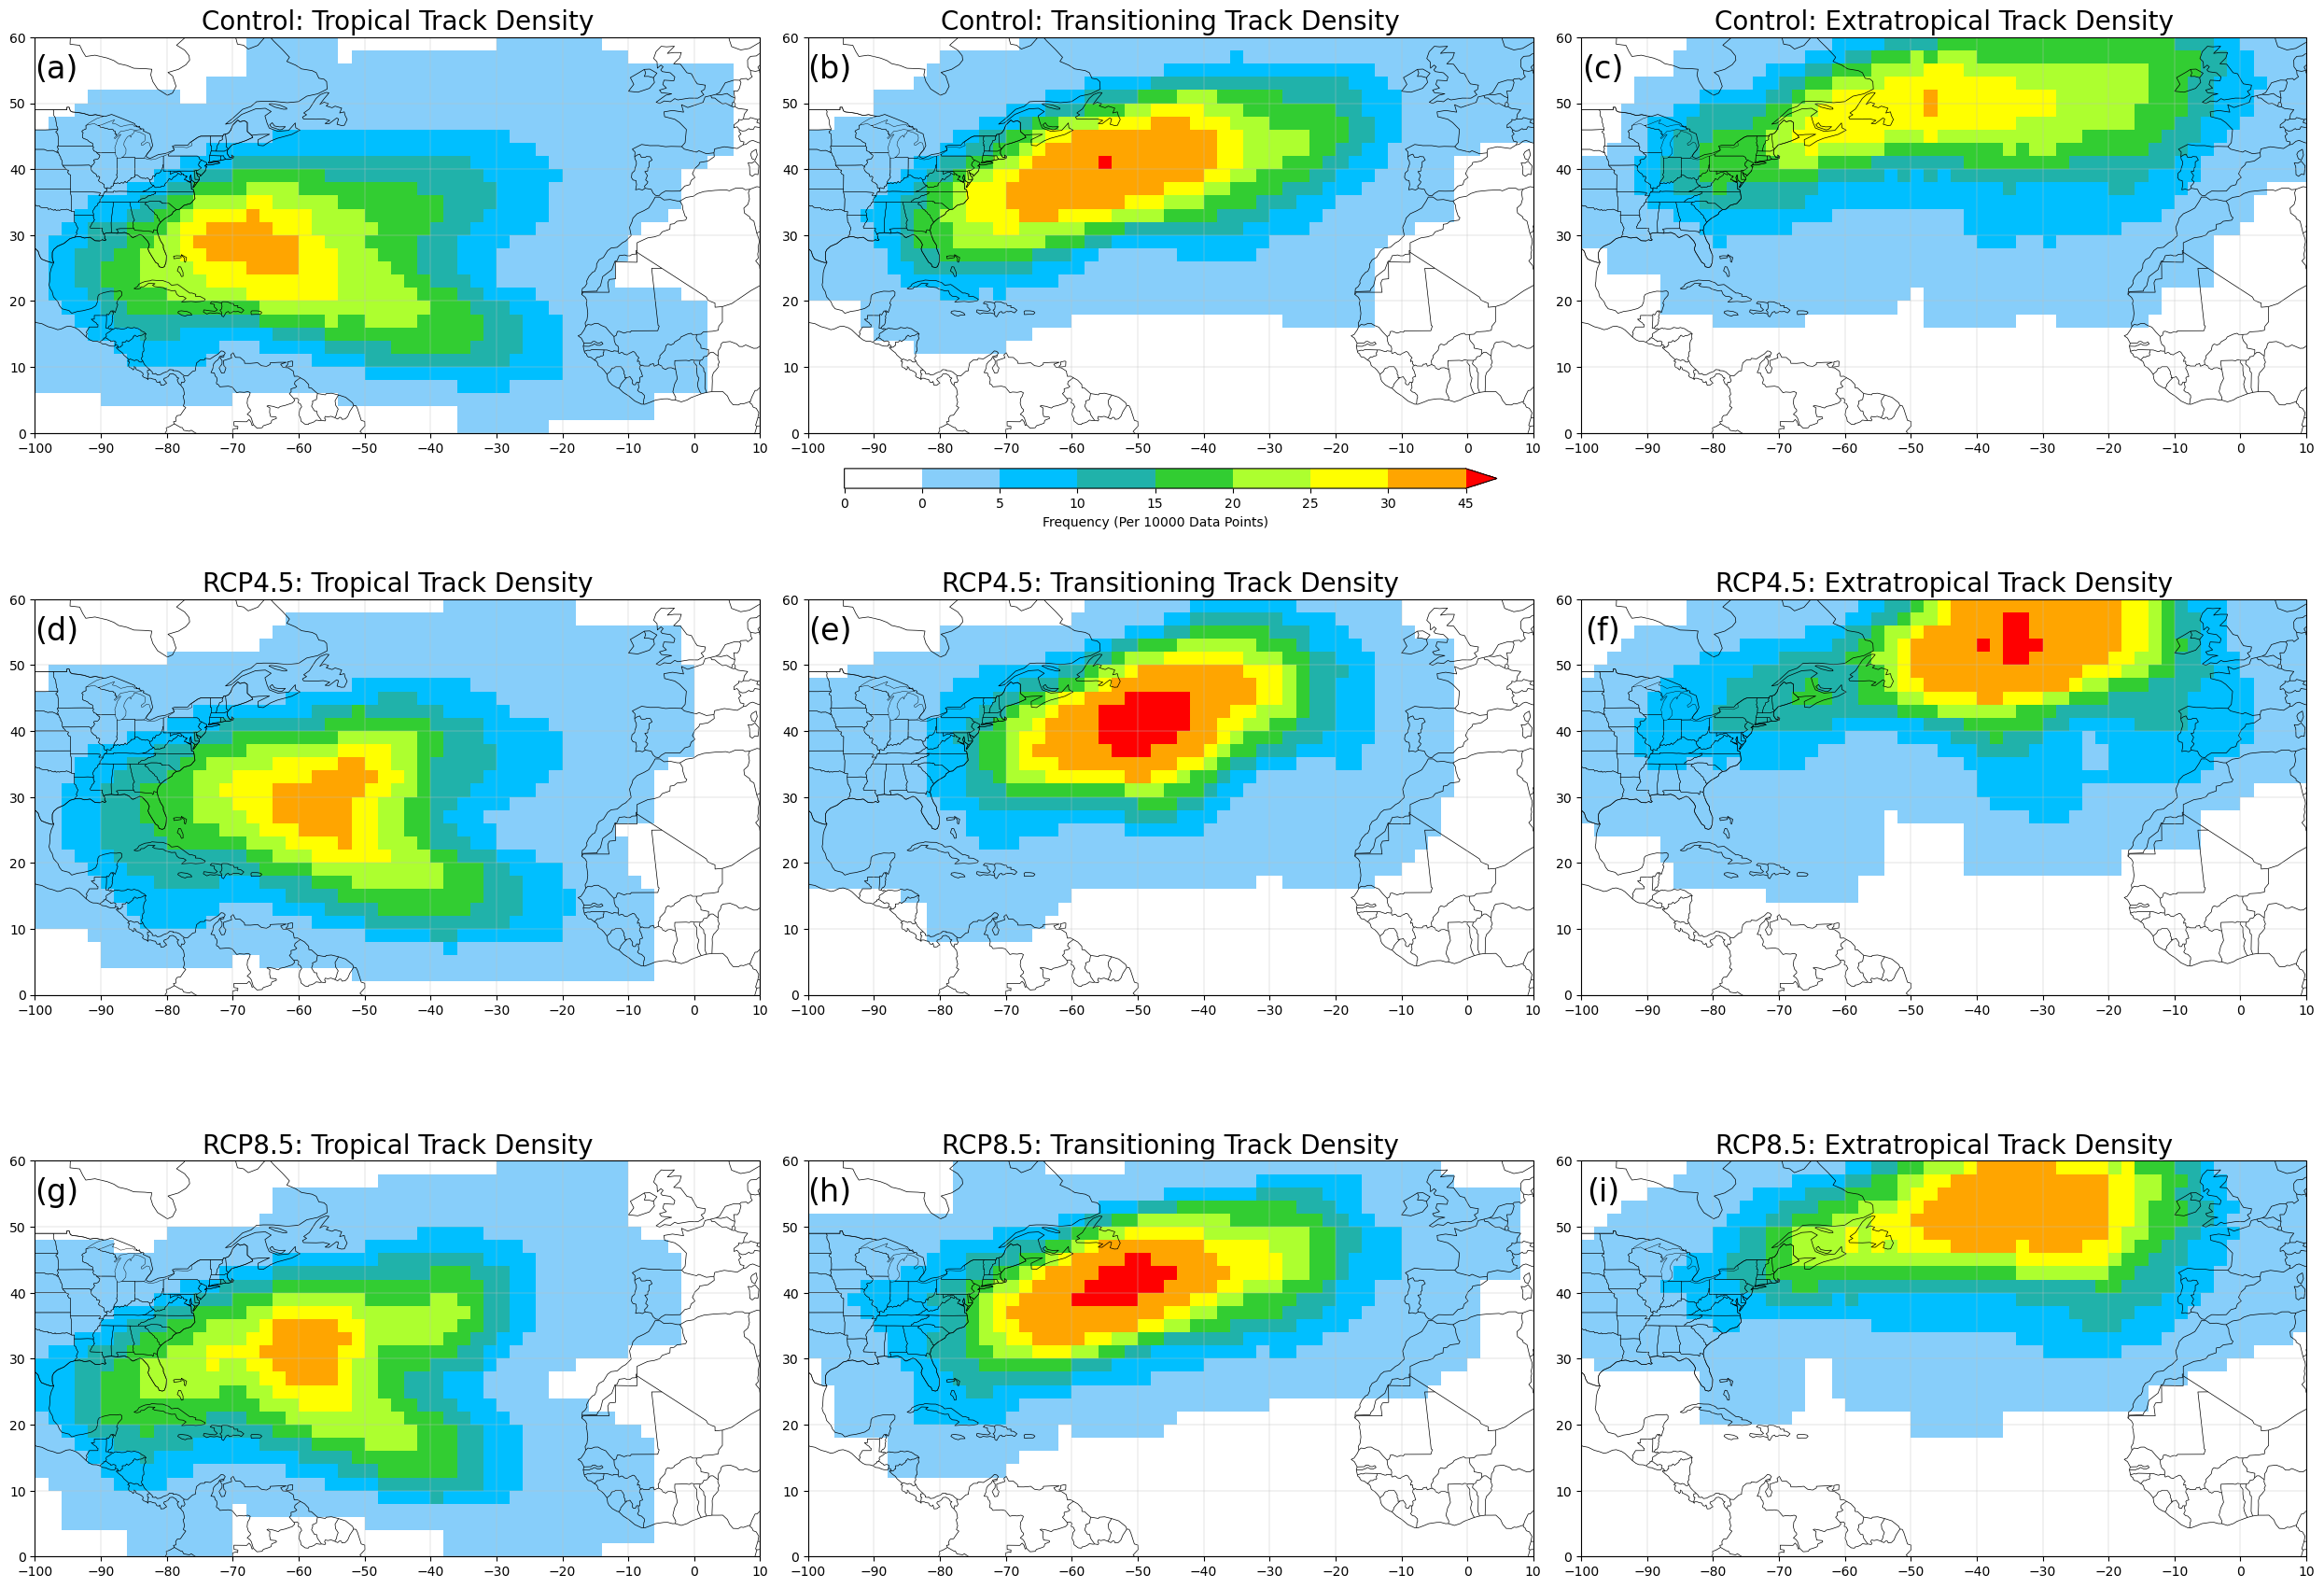

In [22]:
# Plot track density by storm phase
Fig = pyplot.figure(figsize=(25,18))
Phase_Distr_Plot(Control_Data, "Control", 0, Phase_Bounds, Phase_Colours, Lon_Bins, Lat_Bins, True)
Phase_Distr_Plot(RCP45_Data, "RCP4.5", 1, Phase_Bounds, Phase_Colours, Lon_Bins, Lat_Bins, False)
Phase_Distr_Plot(RCP85_Data, "RCP8.5", 2, Phase_Bounds, Phase_Colours, Lon_Bins, Lat_Bins, False)
Fig.tight_layout()
Fig.savefig(Output_Diri+'Track_Density.png', bbox_inches='tight')

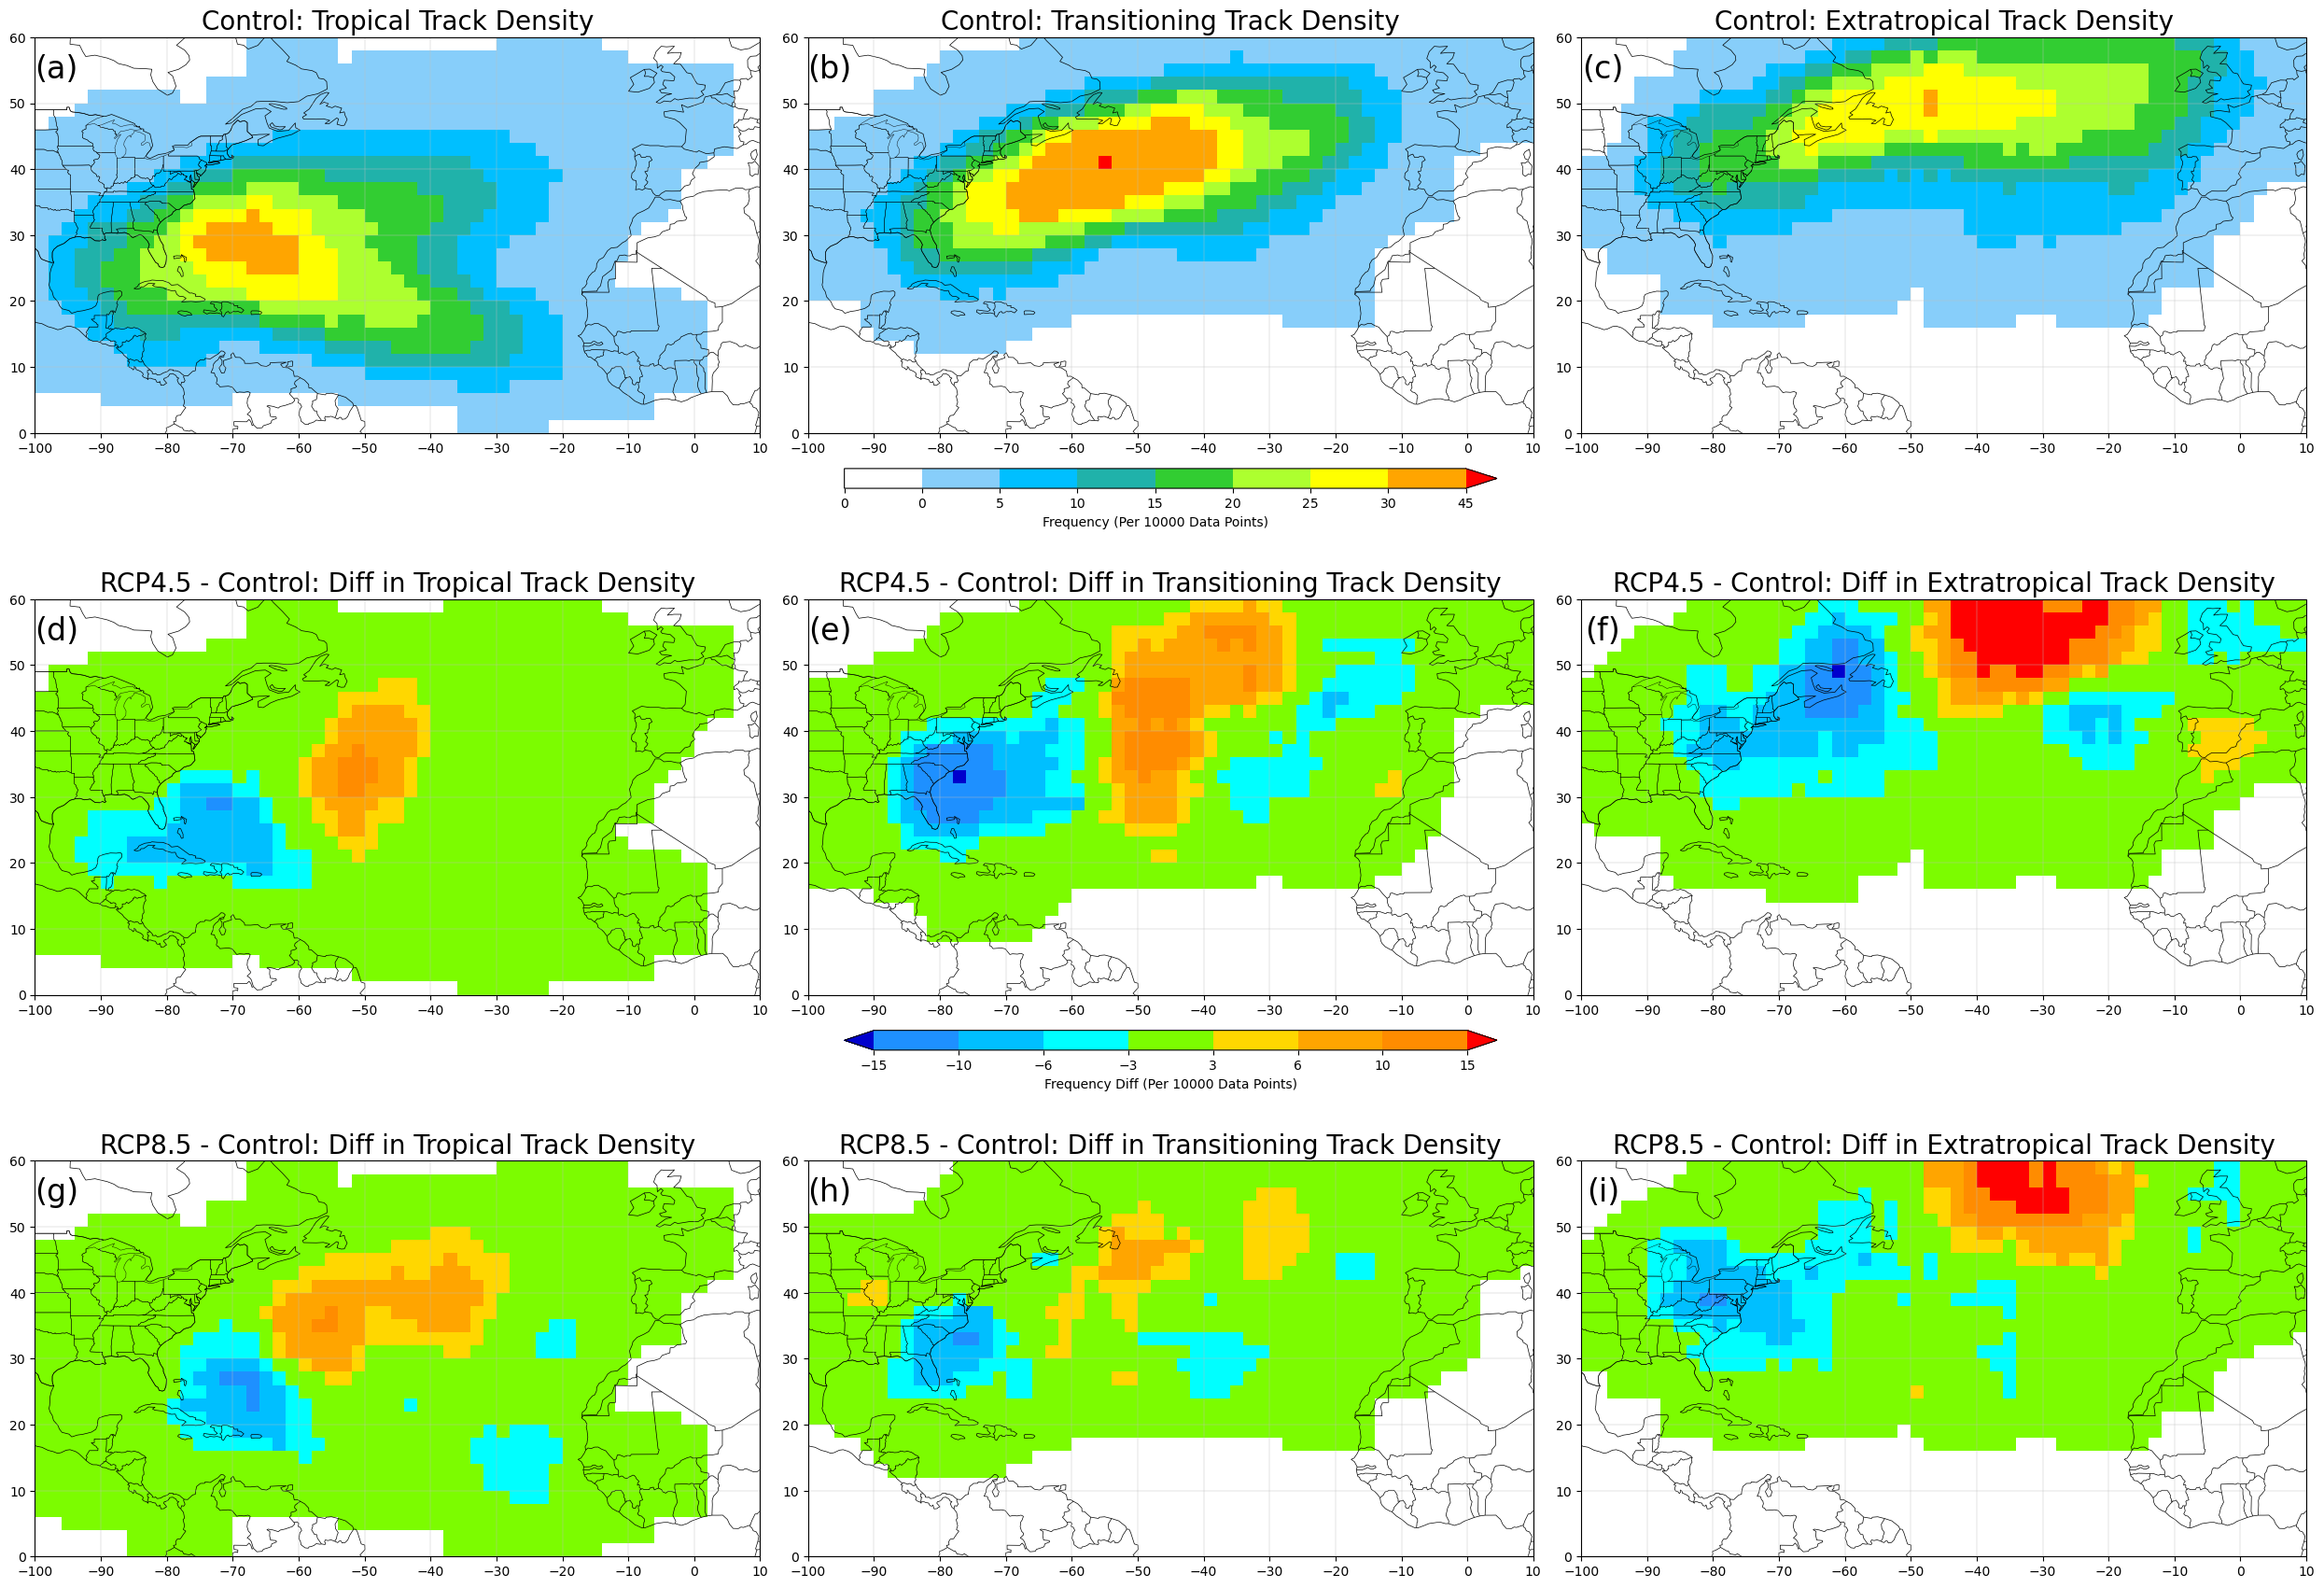

In [23]:
# Plot differences between track densities by storm phase
Fig = pyplot.figure(figsize=(25,18))
Phase_Distr_Plot(Control_Data, "Control", 0, Phase_Bounds, Phase_Colours, Lon_Bins, Lat_Bins, True)
Phase_Diff_Plot(RCP45_Data, Control_Data, "RCP4.5", "Control", 1, Phase_Diff_Bounds, Phase_Diff_Colours, Lon_Bins, Lat_Bins, True)
Phase_Diff_Plot(RCP85_Data, Control_Data, "RCP8.5", "Control", 2, Phase_Diff_Bounds, Phase_Diff_Colours, Lon_Bins, Lat_Bins, False)
Fig.tight_layout()
Fig.savefig(Output_Diri+'Track_Density_Diff.png', bbox_inches='tight')

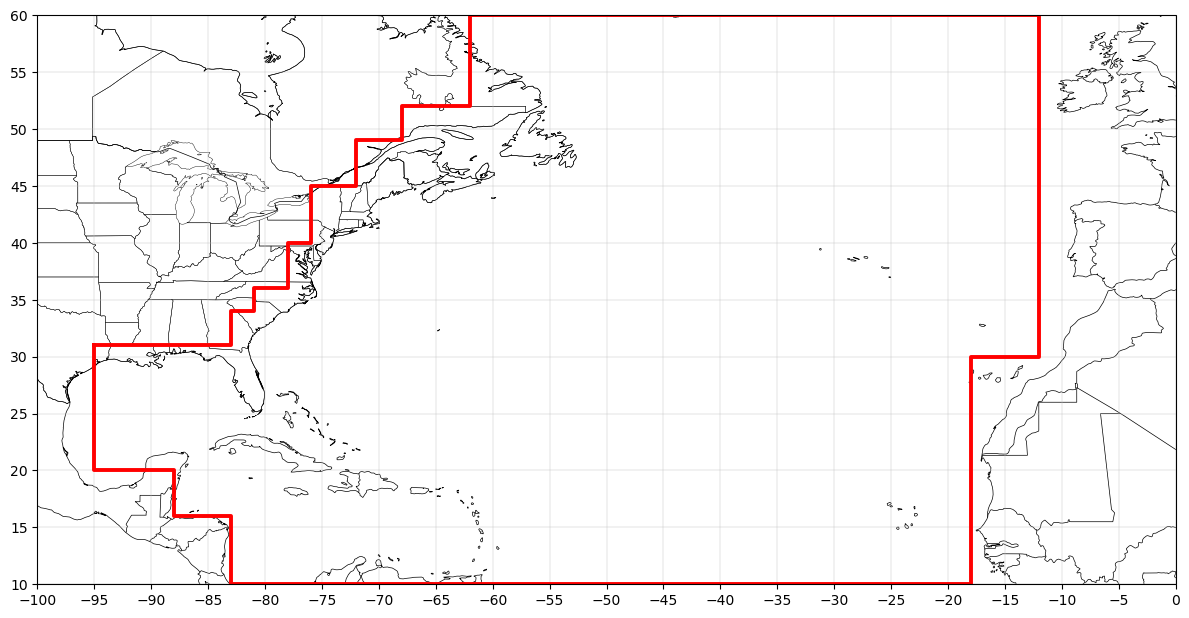

In [24]:
# Plot geographical bounds for Subset C
Fig = pyplot.figure(figsize=(12,8))
Axis = Fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
Axis.coastlines(linewidth=0.5)
Axis.add_feature(cfeature.BORDERS, linewidth=0.5)
Axis.add_feature(cfeature.STATES, linewidth=0.3)
x_Min, x_Max, y_Min, y_Max = -100,0,10,60
x_Axis = Create_Bins(x_Min, x_Max, 5)
y_Axis = Create_Bins(y_Min, y_Max, 5)
pyplot.xticks(x_Axis)
pyplot.yticks(y_Axis)
pyplot.xlim(x_Min,x_Max)
pyplot.ylim(y_Min,y_Max)
pyplot.grid(linewidth=0.3, color='silver', linestyle='-')
pyplot.plot(\
[-95,-83,-83,-81,-81,-78,-78,-76,-76,-72,-72,-68,-68,-62,-62,-12,-12,-18,-18,-83,-83,-88,-88,-95,-95], \
[31,31,34,34,36,36,40,40,45,45,49,49,52,52,60,60,30,30,10,10,16,16,20,20,31], c='red', linewidth=2.8)
Fig.tight_layout()
Fig.savefig(Output_Diri+'Subset_C_Bounds.png', bbox_inches='tight')